## Libraries and File Loading

In [1]:
# function should simply be imported from the other python file at some point 

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.plot import show
import rioxarray as rxr
from dask.diagnostics import ProgressBar

In [2]:
# --- Set file paths ---
# Base directory for project outputs
dir_path = "/global/scratch/users/yougsanghvi"

# Specific folder for attribution results
attribution_output_folderpath = os.path.join(
    dir_path,
    "gdnat_era5_compare_output"
)

# Define the output filename
attribution_output_filename = "merged_data_panel_extended.csv"

# Construct the full file path for the output data
attribution_output_filepath = os.path.join(
    attribution_output_folderpath,
    attribution_output_filename
)

# Define paths for usa county shapefile
usa_county_dir = os.path.join(dir_path, "shapefiles")
usa_county_filename = "tl_2016_us_county_mortality.shp"
usa_county_path = os.path.join(usa_county_dir, usa_county_filename)


regression_beta_fn = "regression_coefficients_USA_poly4_lag11.csv"
regression_beta_fp = os.path.join(dir_path, regression_beta_fn)

# --- Load data ---
# Read the CSV file into a pandas DataFrame
attribution_output_data = pd.read_csv(attribution_output_filepath)

# Load CSV into pandas DataFrame
regression_betas = pd.read_csv(regression_beta_fp)

# Loading in county shapefile
usa_counties = gpd.read_file(usa_county_path)

# --- Data manipulation ---
# Calculate the difference between ERA5 and GDNAT predictions
attribution_output_data['diff_suicide'] = attribution_output_data['y_hat_era5'] - attribution_output_data['y_hat_gdnat']

In [3]:
df_filtered = attribution_output_data[attribution_output_data["year"].between(2000, 2004)]
county_diff = df_filtered.groupby("adm2_id")["diff_suicide"].mean().reset_index()

In [4]:
#Average delta per county

weather_diff = (
    df_filtered.groupby("adm2_id")["temp_diff"]
    .mean()
    .reset_index()
)

## Diagnostics

In [60]:
filtered_weather_diff = weather_diff[(weather_diff['temp_diff'] > 0.7) | (weather_diff['temp_diff'] < 0)]
# Select unique NAME and countyname by adm2_id from original df_filtered
county_info = df_filtered[['adm2_id', 'NAME', 'countyname']].drop_duplicates()

# Merge with filtered_weather_diff on adm2_id
weatherdiff_merged = filtered_weather_diff.merge(county_info, on='adm2_id', how='left')

# sort in ascending
weatherdiff_merged = weatherdiff_merged.sort_values(by='temp_diff', ascending=True)


In [61]:
weatherdiff_merged

,adm2_id,temp_diff,NAME,countyname
16,6089,-3.352749,Shasta,Shasta
7,6017,-2.512698,El Dorado,El Dorado
58,53053,-0.834057,Pierce,Pierce
56,53033,-0.551873,King,King
60,53073,-0.427160,Whatcom,Whatcom
...,...,...,...,...
3,4025,2.043064,Yavapai,Yavapai
2,4019,2.060171,Pima,Pima
24,8041,2.384028,El Paso,El Paso
13,6071,3.754796,San Bernardino,San Bernardino


## Functions 

In [9]:
def plot_county_aggregated_map(
    df,                    # DataFrame with climate/suicide data
    shapefile,             # County shapefile GeoDataFrame
    value_col,             # Column to aggregate & plot
    title,                 # Title for the map
    legend_label,          # Label for the colorbar
    years=None,            # Optional: list or range of years
    vmin=None,             # Optional: fixed min value for colormap
    vmax=None              # Optional: fixed max value for colormap
):
    import matplotlib.pyplot as plt
    import geopandas as gpd

    # 1. Optional year filter
    if years is not None:
        df = df[df["year"].isin(years)]

    # 2. Aggregate value by county
    agg_df = (
        df.groupby("adm2_id")[value_col]
        .mean()
        .reset_index()
    )

    # 3. Merge with shapefile
    shapefile = shapefile.copy()
    shapefile["GEOID"] = shapefile["GEOID"].astype(int)
    gdf = shapefile.merge(agg_df, left_on="GEOID", right_on="adm2_id", how="left")

    # 4. Clip to mainland US
    gdf = gdf.cx[-125:-66, 24:50]

    # 5. Determine color scale
    if vmin is None or vmax is None:
        if gdf[value_col].notna().any():
            max_abs = max(abs(gdf[value_col].min()), abs(gdf[value_col].max()))
        else:
            max_abs = 1
        vmin = -max_abs if vmin is None else vmin
        vmax = max_abs if vmax is None else vmax

    # 6. Plot
    fig, ax = plt.subplots(figsize=(15, 10))
    gdf.plot(
        column=value_col,
        cmap="coolwarm",
        linewidth=0.1,
        edgecolor="0.8",
        legend=True,
        vmin=vmin,
        vmax=vmax,
        ax=ax,
        legend_kwds={"label": legend_label}
    )

    ax.set_title(title, fontsize=16)
    ax.axis("off")
    plt.show()


## Plotting Using Functions

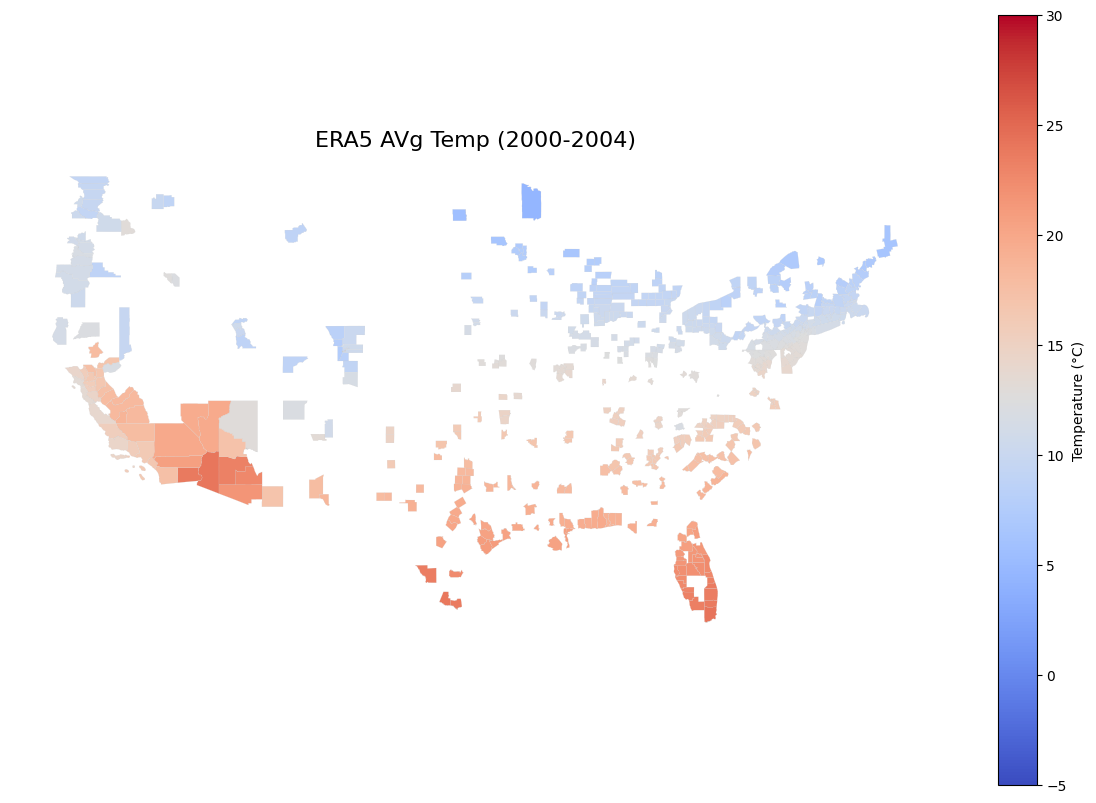

In [10]:
plot_county_aggregated_map(
    df=attribution_output_data,
    shapefile=usa_counties,
    value_col="era5_avg_temp",
    title="ERA5 AVg Temp (2000-2004)",
    legend_label="Temperature (°C)",  
    years=range(2000, 2005),
    vmin=-5,
    vmax=30  
)

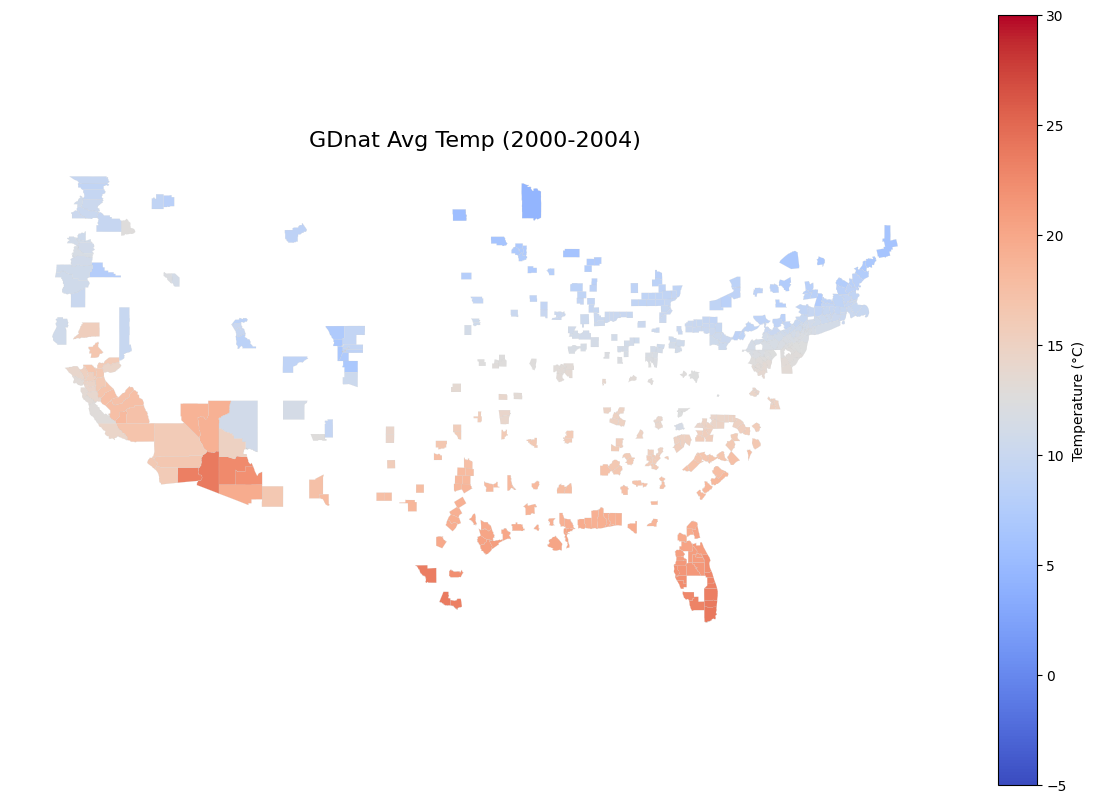

In [11]:
plot_county_aggregated_map(
    df=attribution_output_data,
    shapefile=usa_counties,
    value_col="gdnat_avg_temp",
    title="GDnat Avg Temp (2000-2004)",
    legend_label="Temperature (°C)",  
    years=range(2000, 2005),
    vmin=-5,
    vmax=30  
)

In [7]:
attribution_output_data.columns

Index(['year', 'month', 'num_of_suicide', 'suiciderate', 'adm2_id',
       'statename', 'countyname', 'era5_avg_temp', 'date', 'y_hat_era5',
       'y_hat_gdnat', 'NAME', 'NAMELSAD', 'ID_1', 'ID_2', 'gdnat_avg_temp',
       'temp_diff', 'diff_suicide'],
      dtype='object')

## Plotting

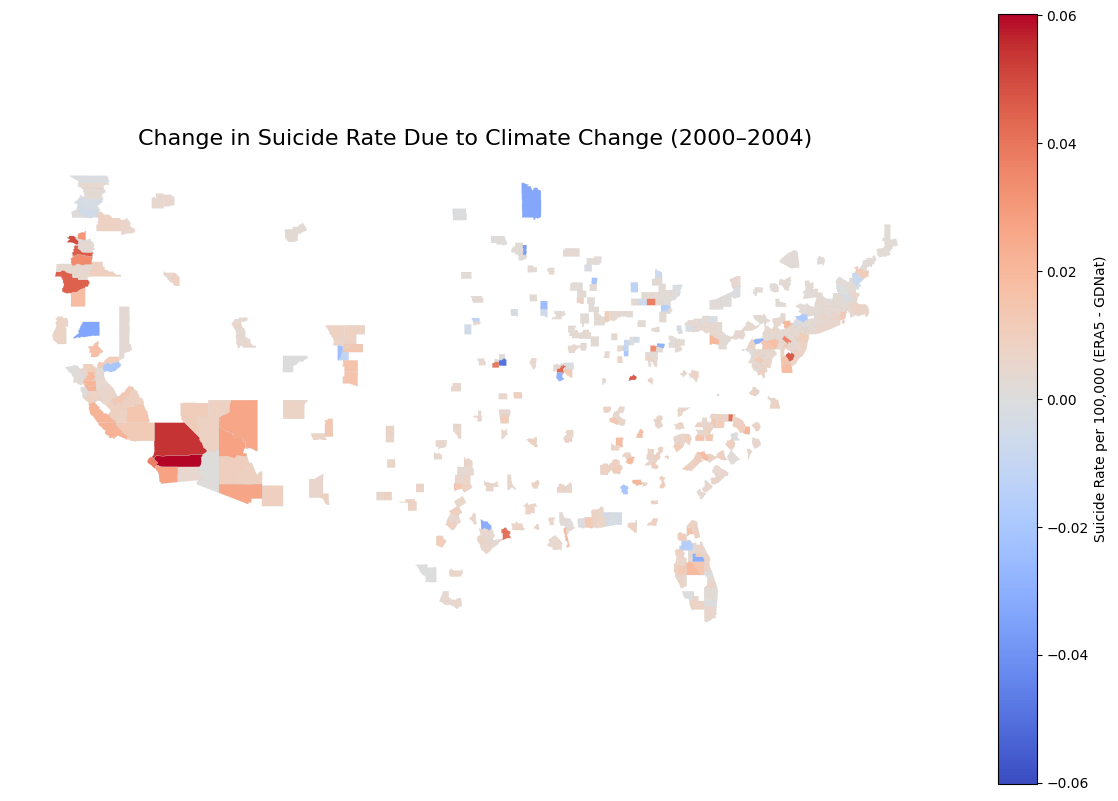

In [37]:


# Merge with shapefile
usa_counties["GEOID"] = usa_counties["GEOID"].astype(int)
gdf_merged = usa_counties.merge(county_diff, left_on="GEOID", right_on="adm2_id", how="left")

# clipping to mainland
gdf_merged = gdf_merged.cx[-125:-66, 24:50]  # using geopandas .cx to filter by bbox

# Plot
max_abs = max(abs(gdf_merged["diff_suicide"].min()), abs(gdf_merged["diff_suicide"].max()))

fig, ax = plt.subplots(figsize=(15, 10))
gdf_merged.plot(
    column="diff_suicide",
    cmap="coolwarm",
    linewidth=0.1,
    edgecolor="0.8",
    legend=True,
    vmin=-max_abs,
    vmax=max_abs,
    ax=ax,
    legend_kwds={"label": "Suicide Rate per 100,000 (ERA5 - GDNat)"}
)

ax.set_title("Change in Suicide Rate Due to Climate Change (2000–2004)", fontsize=16)
ax.axis("off")

plt.show()


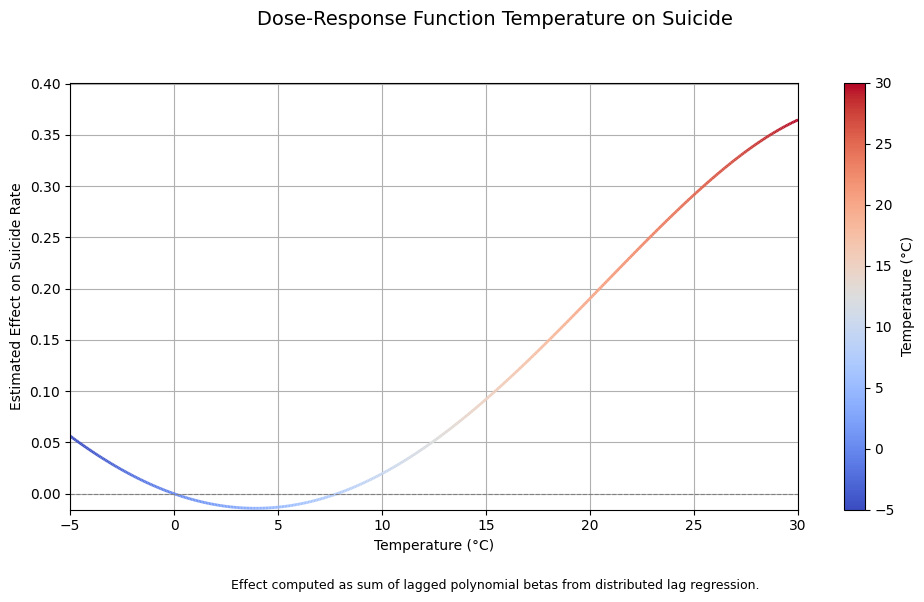

In [67]:
# -------------------------------
# 2. Extract polynomial order and lag from term names
# -------------------------------
def extract_poly_and_lag(term):
    m = re.match(r"tavg_poly(\d)_l(\d+)", term)
    return (int(m.group(1)), int(m.group(2))) if m else (None, None)

regression_betas['poly'], regression_betas['lag'] = zip(*regression_betas['term'].map(extract_poly_and_lag))
regression_betas = regression_betas.dropna(subset=['poly', 'lag'])

# -------------------------------
# 3. Sum coefficients across all lags, by polynomial degree
# -------------------------------
sum_betas = regression_betas.groupby('poly')['beta'].sum().sort_index()
betas = [sum_betas.get(i, 0) for i in range(1, 5)]  # [poly1, poly2, poly3, poly4]

# -------------------------------
# 4. Define dose-response function
# -------------------------------
def dose_response_curve(x, coefs):
    return sum(coef * (x ** i) for i, coef in enumerate(coefs, start=1))

# -------------------------------
# 5. Compute x and y values
# -------------------------------
x_vals = np.linspace(-5, 30, 500)
y_vals = dose_response_curve(x_vals, betas)

# -------------------------------
# 6. Create a gradient-colored line
# -------------------------------
points = np.array([x_vals, y_vals]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = plt.Normalize(x_vals.min(), x_vals.max())
lc = LineCollection(segments, cmap='coolwarm', norm=norm)
lc.set_array(x_vals)
lc.set_linewidth(2)

# -------------------------------
# 7. Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.set_xlim(x_vals.min(), x_vals.max())
ax.set_ylim(y_vals.min() - 0.1 * abs(y_vals.min()), y_vals.max() + 0.1 * abs(y_vals.max()))
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Titles and labels
fig.suptitle("Dose-Response Function Temperature on Suicide", fontsize=14)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Estimated Effect on Suicide Rate")

# Add colorbar
cbar = fig.colorbar(lc, ax=ax)
cbar.set_label("Temperature (°C)")

# Optional bottom caption
plt.figtext(0.5, 0.01,
            "Effect computed as sum of lagged polynomial betas from distributed lag regression.",
            ha='center', va='bottom', fontsize=9)

plt.grid(True)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # leave room for figtext and title
plt.show()


In [45]:
df_filtered

,year,month,num_of_suicide,suiciderate,adm2_id,statename,countyname,era5_avg_temp,date,y_hat_era5,y_hat_gdnat,NAME,NAMELSAD,ID_1,ID_2,gdnat_avg_temp,temp_diff,diff_suicide
2064,2000,1,7,NaN,36005,NaN,NaN,-1.302415,2000-01-01,0.012074,0.028112,Bronx,Bronx County,36.0,5.0,-1.971318,0.668903,-0.016038
2065,2000,1,6,NaN,36047,NaN,NaN,-0.808112,2000-01-01,0.021165,0.030572,Kings,Kings County,36.0,47.0,-1.647486,0.839374,-0.009408
2066,2000,1,14,NaN,36061,NaN,NaN,-1.332174,2000-01-01,0.016479,0.028297,New York,New York County,36.0,61.0,-2.079559,0.747385,-0.011818
2067,2000,1,16,NaN,36081,NaN,NaN,-0.726566,2000-01-01,0.024105,0.030915,Queens,Queens County,36.0,81.0,-1.418970,0.692404,-0.006809
2068,2000,1,1,NaN,36085,NaN,NaN,-0.609799,2000-01-01,0.040533,0.032836,Richmond,Richmond County,36.0,85.0,-1.248591,0.638792,0.007698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438523,2004,8,0,0.000000,4027,Arizona,Yuma,34.048073,2004-08-01,0.463338,0.438879,Yuma,Yuma County,4.0,27.0,33.062820,0.985253,0.024459
438524,2004,9,3,1.555992,4027,Arizona,Yuma,31.281822,2004-09-01,0.423964,0.396452,Yuma,Yuma County,4.0,27.0,30.290519,0.991303,0.027512
438525,2004,10,2,1.037328,4027,Arizona,Yuma,23.517010,2004-10-01,0.287978,0.277792,Yuma,Yuma County,4.0,27.0,22.880013,0.636996,0.010186
438526,2004,11,3,1.555992,4027,Arizona,Yuma,15.723304,2004-11-01,0.178925,0.183754,Yuma,Yuma County,4.0,27.0,15.534232,0.189072,-0.004830


In [42]:
attribution_output_data

,year,month,num_of_suicide,suiciderate,adm2_id,statename,countyname,era5_avg_temp,date,y_hat_era5,y_hat_gdnat,NAME,NAMELSAD,ID_1,ID_2,gdnat_avg_temp,temp_diff,diff_suicide
0,1980,1,26,NaN,2013,NaN,NaN,-3.801913,1980-01-01,-0.077774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1980,1,0,NaN,13001,NaN,NaN,10.302341,1980-01-01,0.066440,0.137301,Appling,Appling County,13.0,1.0,10.565320,-0.262979,-0.070861
2,1980,1,0,NaN,13083,NaN,NaN,5.058186,1980-01-01,0.024402,0.094541,Dade,Dade County,13.0,83.0,5.324480,-0.266294,-0.070139
3,1980,1,0,NaN,17039,NaN,NaN,-2.712035,1980-01-01,-0.029225,0.084362,De Witt,De Witt County,17.0,39.0,-2.239715,-0.472320,-0.113587
4,1980,1,0,NaN,22031,NaN,NaN,9.141883,1980-01-01,0.066957,0.135230,De Soto,De Soto Parish,22.0,31.0,9.589038,-0.447155,-0.068273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438847,1988,8,0,0.000000,46137,South Dakota,Ziebach,23.193239,1988-08-01,0.146365,0.150497,Ziebach,Ziebach County,46.0,137.0,23.484011,-0.290772,-0.004132
438848,1988,9,0,0.000000,46137,South Dakota,Ziebach,15.805217,1988-09-01,0.093682,0.093388,Ziebach,Ziebach County,46.0,137.0,16.136263,-0.331046,0.000294
438849,1988,10,1,45.620438,46137,South Dakota,Ziebach,8.787710,1988-10-01,0.084011,0.094899,Ziebach,Ziebach County,46.0,137.0,8.858979,-0.071269,-0.010888
438850,1988,11,0,0.000000,46137,South Dakota,Ziebach,-0.113487,1988-11-01,0.064230,0.065947,Ziebach,Ziebach County,46.0,137.0,-0.298330,0.184843,-0.001717


In [49]:
# Clean both columns: lowercase, remove whitespace
county_clean = df_filtered['countyname'].astype(str).str.lower().str.replace(r'\s+', '', regex=True)
name_clean = df_filtered['NAME'].astype(str).str.lower().str.replace(r'\s+', '', regex=True)

# Combine into a DataFrame
county_check = pd.DataFrame({'clean_countyname': county_clean, 'clean_NAME': name_clean})

# Drop rows where either is missing
county_check = county_check.dropna()

# Compare and filter matching rows
county_check['match'] = county_check['clean_countyname'] == county_check['clean_NAME']

# Unique matches
matched_counties = county_check[county_check['match']]['clean_countyname'].unique()
total_counties = county_check['clean_countyname'].unique()

# Count and report
num_matched = len(matched_counties)
num_total = len(total_counties)
match_pct = num_matched / num_total * 100

print(f"Matched unique counties: {num_matched} out of {num_total}")
print(f"Match rate: {match_pct:.2f}%")

Matched unique counties: 405 out of 439
Match rate: 92.26%


In [50]:
non_matching_unique = df_filtered[~county_clean.isin(matched_counties)][['NAME', 'countyname']].drop_duplicates()

In [51]:
non_matching_unique

,NAME,countyname
2064,Bronx,NaN
2065,Kings,NaN
2066,New York,NaN
2067,Queens,NaN
2068,Richmond,NaN
7620,Alexandria,Alexandria city
8244,NaN,Allegan
10956,Anchorage,Anchorage Municipality
15972,NaN,Ashtabula
19980,Baltimore,Baltimore city


In [52]:
summary_stats = df_filtered['temp_diff'].describe()
print(summary_stats)


count    30300.000000
mean         0.392739
std          0.578041
min         -4.746676
25%          0.096008
50%          0.383076
75%          0.650415
max          6.740621
Name: temp_diff, dtype: float64


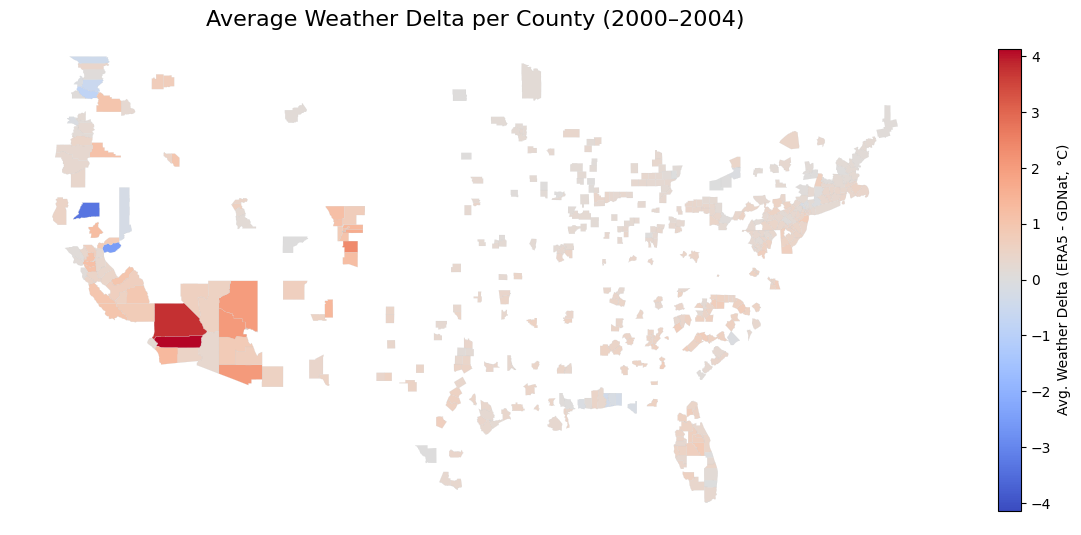

In [12]:
# Step 4: Merge with county shapefile
usa_counties["GEOID"] = usa_counties["GEOID"].astype(int)
weather_merged = usa_counties.merge(weather_diff, left_on="GEOID", right_on="adm2_id", how="left")

# Step 5: Filter to mainland bounding box
mainland = weather_merged.cx[-125:-66, 24:50]

vmax = mainland["temp_diff"].abs().max()
vmin = -vmax

fig, ax = plt.subplots(figsize=(15, 10))
mainland.plot(
    column="temp_diff",
    cmap="coolwarm",
    linewidth=0.1,
    edgecolor="0.8",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Avg. Weather Delta (ERA5 - GDNat, °C)", "shrink": 0.6},
    vmin=vmin,
    vmax=vmax,
)

ax.set_title("Average Weather Delta per County (2000–2004)", fontsize=16)
ax.axis("off")
plt.show()


In [9]:
weather_filtered.columns

Index(['year', 'month', 'order_1_avg.x', 'date.x', 'y_hat_era5', 'poly_id',
       'y_hat_gdnat', 'NAME', 'NAMELSAD', 'ID_1', 'ID_2', 'date.y',
       'order_1_avg.y', 'diff_suicide', 'weather_delta'],
      dtype='object')

In [13]:
weather_filtered["poly_id"].nunique()

3228

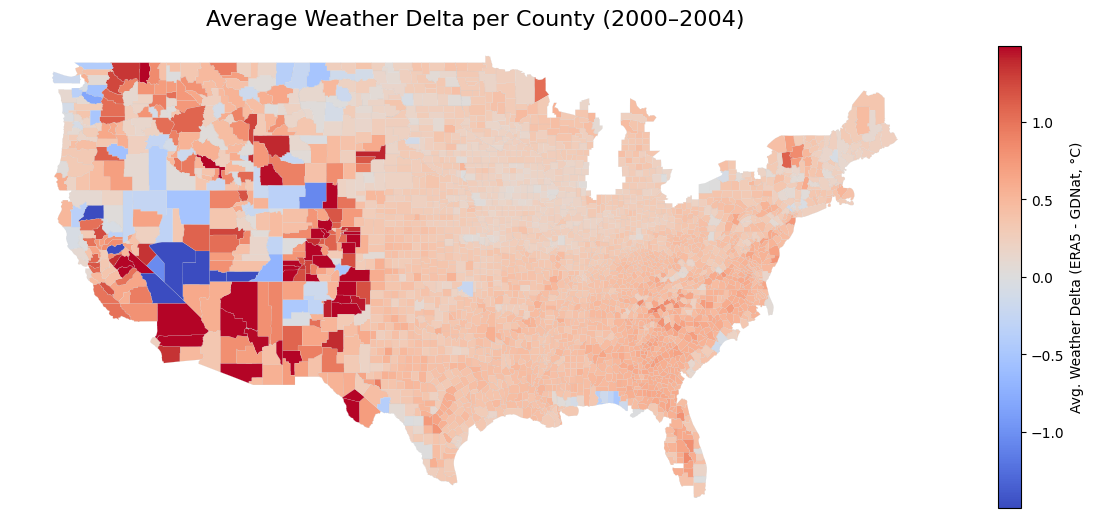

In [11]:
# Step 1: Compute clipping bounds (1st and 99th percentile)
lower, upper = mainland["weather_delta"].quantile([0.01, 0.99])
max_abs = max(abs(lower), abs(upper))  # symmetric bounds around 0

# Step 2: Plot with symmetric, clipped color scale
fig, ax = plt.subplots(figsize=(15, 10))
mainland.plot(
    column="weather_delta",
    cmap="coolwarm",
    linewidth=0.1,
    edgecolor="0.8",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Avg. Weather Delta (ERA5 - GDNat, °C)", "shrink": 0.6},
    vmin=-max_abs,
    vmax= max_abs,
)

ax.set_title("Average Weather Delta per County (2000–2004)", fontsize=16)
ax.axis("off")
plt.show()


In [13]:
print(gdf_merged.columns)

Index(['ID_1', 'ID_2', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'ID_0', 'geometry', 'adm2_id',
       'diff_suicide'],
      dtype='object')


In [16]:
print(attribution_output_data.columns)

Index(['year', 'month', 'num_of_suicide', 'suiciderate', 'adm2_id',
       'statename', 'countyname', 'date', 'y_hat_era5', 'y_hat_gdnat', 'ID_1',
       'ID_2', 'diff_suicide'],
      dtype='object')


In [4]:
era5_folderpath = os.path.join("merged", "USA")
era5_filename = "USA_adm2_1968_2004_monthly.dta"
era5_filepath = os.path.join(dir_path, era5_folderpath, era5_filename)

# Load the Stata file
df = pd.read_stata(era5_filepath)



# Count unique counties
unique_counties = df['adm2_id'].nunique()
print(f"Unique counties from 2000 to 2003: {unique_counties}")


Unique counties from 2000 to 2003: 3142


In [8]:

era5_filepath = "/global/scratch/users/yougsanghvi/data/climatedata/USA/usa_adm2_poly_1968_2004_monthly.dta"

# Load the Stata file
df_raw = pd.read_stata(era5_filepath)


# Count unique counties
unique_counties = df_raw['adm2_id'].nunique()
print(f"Unique counties from 2000 to 2003: {unique_counties}")


Unique counties from 2000 to 2003: 324


In [9]:
df_raw

,year,month,tavg_poly1_aw,tavg_poly2_aw,tavg_poly3_aw,tavg_poly4_aw,tavg_poly5_aw,prec_poly1_aw,prec_poly2_aw,prec_poly3_aw,leapyear,ndays,grow,season,adm1_id,adm2_id
0,1968,1,6.458818,62.418747,677.514404,7992.428711,9.905072e+04,89.011955,1586.830566,35995.804688,1.0,31.0,0.0,4.0,1.0,1.0
1,1968,1,10.066875,121.516609,1609.860840,22606.095703,3.299709e+05,85.782677,1712.859375,43252.351562,1.0,31.0,0.0,4.0,1.0,3.0
2,1968,1,7.175480,72.892372,826.489746,10062.567383,1.281844e+05,61.893791,972.821045,23524.193359,1.0,31.0,0.0,4.0,1.0,5.0
3,1968,1,5.989792,58.516277,635.804993,7540.107422,9.356980e+04,92.698273,1367.166138,26582.931641,1.0,31.0,0.0,4.0,1.0,7.0
4,1968,1,3.757343,38.983032,379.981079,4369.229004,5.088843e+04,139.432739,3421.335205,121390.554688,1.0,31.0,0.0,4.0,1.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433227,2004,12,24.640142,607.303589,14972.283203,369223.906250,9.107752e+06,58.141262,175.866150,836.815491,1.0,31.0,0.0,4.0,72.0,151.0
1433228,2004,12,25.142912,632.571167,15924.923828,401157.875000,1.011158e+07,18.806017,24.189135,62.274540,1.0,31.0,0.0,4.0,72.0,153.0
1433229,2004,12,25.640455,657.599304,16869.662109,432872.875000,1.111022e+07,50.446594,231.504684,1965.546753,1.0,31.0,0.0,4.0,78.0,10.0
1433230,2004,12,25.434288,647.077820,16466.861328,419162.687500,1.067264e+07,50.390575,199.474838,1378.813477,1.0,31.0,0.0,4.0,78.0,20.0


In [26]:
geoids = set(usa_counties["GEOID"])
adm2_ids = set(county_diff["adm2_id"])

print("adm2_ids not in GEOID:", len(adm2_ids - geoids))
print("GEOID not in adm2_ids:", len(geoids - adm2_ids))
print("Overlap:", len(geoids & adm2_ids))
print("Total adm2_id:", len(adm2_ids))
print("Total GEOID:", len(geoids))

# Number of unique counties in the filtered dataset (2001-2004)
num_counties_filtered = df_filtered['adm2_id'].nunique()
print(f"Unique counties in filtered data: {num_counties_filtered}")

# Number of unique counties after grouping and averaging
num_counties_meaned = county_diff['adm2_id'].nunique()
print(f"Unique counties after averaging: {num_counties_meaned}")

# Number of unique counties after grouping and averaging
num_counties_og = attribution_output_data['adm2_id'].nunique()
print(f"Unique counties originally: {num_counties_og}")



adm2_ids not in GEOID: 0
GEOID not in adm2_ids: 2723
Overlap: 505
Total adm2_id: 505
Total GEOID: 3228
Unique counties in filtered data: 505
Unique counties after averaging: 505
Unique counties originally: 3040


In [29]:
gdf_merged
print(gdf_merged.isna().any())

ID_1            False
ID_2            False
COUNTYNS        False
GEOID           False
NAME            False
NAMELSAD        False
LSAD            False
CLASSFP         False
MTFCC           False
CSAFP            True
CBSAFP           True
METDIVFP         True
FUNCSTAT        False
ALAND           False
AWATER          False
INTPTLAT        False
INTPTLON        False
ID_0            False
geometry        False
adm2_id          True
diff_suicide     True
dtype: bool


In [26]:
# Filter years 2001-2004
df_filtered = attribution_output_data[attribution_output_data["year"].between(2001, 2004)]

# Get sorted unique year-month pairs
unique_times = df_filtered[["year", "month"]].drop_duplicates().sort_values(["year", "month"])

print(unique_times.reset_index(drop=True))


    year  month
0   2001      1
1   2001      2
2   2001      3
3   2001      4
4   2001      5
5   2001      6
6   2001      7
7   2001      8
8   2001      9
9   2001     10
10  2001     11
11  2001     12
12  2002      1
13  2002      2
14  2002      3
15  2002      4
16  2002      5
17  2002      6
18  2002      7
19  2002      8
20  2002      9
21  2002     10
22  2002     11
23  2002     12
24  2003      1
25  2003      2
26  2003      3
27  2003      4
28  2003      5
29  2003      6
30  2003      7
31  2003      8
32  2003      9
33  2003     10
34  2003     11
35  2003     12
36  2004      1
37  2004      2
38  2004      3
39  2004      4
40  2004      5
41  2004      6
42  2004      7
43  2004      8
44  2004      9
45  2004     10
46  2004     11
47  2004     12


## Line plots

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_time_series_by_location(
    data_df,               # The main DataFrame containing your time series data (e.g., stagg_usa_data)
    location_mapping_df,   # DataFrame with location names and IDs (e.g., usa_counties)
    location_name_col,     # Column name in location_mapping_df for the human-readable name (e.g., "NAME")
    location_id_col_map,   # Column name in location_mapping_df for the ID (e.g., "GEOID")
    data_id_col,           # Column name in data_df for the ID (e.g., "poly_id")
    target_location_name,  # The specific name of the location to plot (e.g., "New York")
    year_col,              # Column name for the year (e.g., "year")
    month_col,             # Column name for the month (e.g., "month")
    time_series_value_col, # Column name for the time series value to plot (e.g., "order_1_daily_avg")
    plot_title="Time Series Plot", # Full title for the plot
    y_label="Value",       # Y-axis label
    aggregate_annually=False, # If True, data will be averaged annually
    start_year=None,       # New parameter: Optional start year for filtering
    end_year=None          # New parameter: Optional end year for filtering
):
    """
    Generates a time series plot for a specific location within a dataset,
    with options to aggregate data annually and filter by a year range.

    Args:
        data_df (pd.DataFrame): The DataFrame containing the time series data.
        location_mapping_df (pd.DataFrame): DataFrame containing location names and their corresponding IDs.
        location_name_col (str): The name of the column in `location_mapping_df` that holds the location's human-readable name.
        location_id_col_map (str): The name of the column in `location_mapping_df` that holds the location's ID.
        data_id_col (str): The name of the column in `data_df` that holds the location's ID.
        target_location_name (str): The specific name of the location (e.g., "New York", "Alameda County")
                                    for which to generate the plot.
        year_col (str): The name of the column in `data_df` that holds the year.
        month_col (str): The name of the column in `data_df` that holds the month.
        time_series_value_col (str): The name of the column in `data_df` that holds the
                                     time series values to be plotted.
        plot_title (str, optional): The complete title for the plot. Defaults to "Time Series Plot".
        y_label (str, optional): The label for the Y-axis. Defaults to "Value".
        aggregate_annually (bool, optional): If True, the `time_series_value_col` will be
                                             averaged annually before plotting. Defaults to False.
        start_year (int, optional): The starting year for the data range (inclusive). If None, no lower bound.
        end_year (int, optional): The ending year for the data range (inclusive). If None, no upper bound.

    Returns:
        None: Displays the plot.
    """
    try:
        # Find the specific location ID directly by name from the mapping DataFrame
        chosen_location_id = location_mapping_df.loc[
            location_mapping_df[location_name_col] == target_location_name, location_id_col_map
        ].values

        if len(chosen_location_id) == 0:
            print(f"Error: Location '{target_location_name}' not found in the mapping data.")
            return
        chosen_location_id = chosen_location_id[0]

        print(f"Found ID for {target_location_name}: {chosen_location_id}")

        # Filter the main data for the chosen location
        chosen_location_data = data_df[data_df[data_id_col] == chosen_location_id].copy()

        if chosen_location_data.empty:
            print(f"Error: No data found for ID '{chosen_location_id}' ({target_location_name}) in the main dataset.")
            return

        # Apply year range filtering if specified
        if start_year is not None:
            chosen_location_data = chosen_location_data[chosen_location_data[year_col] >= start_year]
        if end_year is not None:
            chosen_location_data = chosen_location_data[chosen_location_data[year_col] <= end_year]

        if chosen_location_data.empty:
            print(f"Warning: No data remaining for ID '{chosen_location_id}' ({target_location_name}) after applying year filters ({start_year}-{end_year}).")
            return


        print(f"Data for {target_location_name} (first 5 rows):")
        print(chosen_location_data.head())

        if aggregate_annually:
            print(f"Aggregating '{time_series_value_col}' annually by average...")
            chosen_location_data = chosen_location_data.groupby(year_col)[time_series_value_col].mean().reset_index()
            # Create a datetime column using only the year for aggregated data
            chosen_location_data["date"] = pd.to_datetime(chosen_location_data[year_col], format='%Y')
            # Adjust plot title for aggregated data
            current_plot_title = f"Annual Average {plot_title.replace('Monthly Average', '').strip()} - {target_location_name}"
        else:
            # Sort by year and month for non-aggregated data
            chosen_location_data = chosen_location_data.sort_values([year_col, month_col])
            # Create a datetime column for plotting
            chosen_location_data["date"] = pd.to_datetime(
                dict(
                    year=chosen_location_data[year_col],
                    month=chosen_location_data[month_col],
                    day=1 # Assume first day of the month for date creation
                )
            )
            current_plot_title = plot_title


        # Plot
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(
            chosen_location_data["date"],
            chosen_location_data[time_series_value_col],
            marker="o",
            linestyle="-"
        )

        ax.set_title(current_plot_title)
        ax.set_xlabel("Date")
        ax.set_ylabel(y_label)
        ax.grid(True)

        plt.tight_layout() # Adjust layout to prevent labels from overlapping
        plt.show()

    except KeyError as e:
        print(f"Error: Missing expected column - {e}. Please check your column names.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


--- Example 1: Plotting New York County's Impact ---
Found ID for New York: 36061
Data for New York (first 5 rows):
        year  month  y_hat_gdnat  poly_id_int  num_of_suicide  suiciderate  \
538189  1980      1     0.070416        36061             0.0          NaN   
538190  1980      2     0.043043        36061             0.0          NaN   
538191  1980      3     0.115166        36061             0.0          NaN   
538192  1980      4     0.153423        36061             0.0          NaN   
538193  1980      5     0.157832        36061             0.0          NaN   

       statename countyname        date  y_hat_era5  diff_suicide  
538189       NaN        NaN  1980-01-01    0.010602     -0.059814  
538190       NaN        NaN  1980-02-01    0.025492     -0.017551  
538191       NaN        NaN  1980-03-01    0.023391     -0.091775  
538192       NaN        NaN  1980-04-01    0.046757     -0.106666  
538193       NaN        NaN  1980-05-01    0.119414     -0.038418  
Aggrega

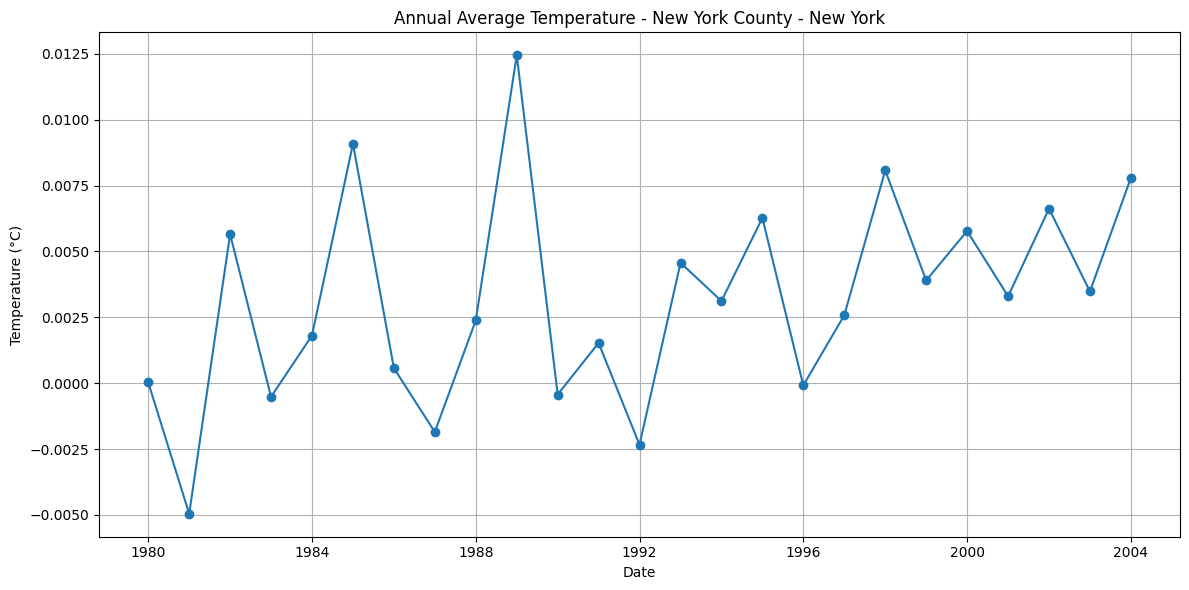

In [32]:
print("--- Example 1: Plotting New York County's Impact ---")
plot_time_series_by_location(
    data_df=attribution_output_data,
    location_mapping_df=usa_counties,
    location_name_col="NAME",
    location_id_col_map="GEOID",
    data_id_col="poly_id_int",
    target_location_name="New York", 
    year_col="year",
    month_col="month",
    time_series_value_col="diff_suicide",
    plot_title="Monthly Average Temperature - New York County", # Full custom title
    y_label="Temperature (°C)",
    aggregate_annually = True,
    start_year = 1980 # need to investiage some issues in 1979
)

In [36]:
attribution_output_data.isnull().sum()

year                   0
month                  0
y_hat_gdnat        48008
poly_id_int            0
num_of_suicide    514111
suiciderate       519151
statename         516631
countyname        516631
date              514111
y_hat_era5        514111
diff_suicide      562119
dtype: int64

,year,month,num_of_suicide,suiciderate,adm2_id,statename,countyname,era5_avg_temp,date,y_hat_era5,y_hat_gdnat,NAME,NAMELSAD,ID_1,ID_2,gdnat_avg_temp,temp_diff,diff_suicide
2065,2000,1,6,NaN,36047,NaN,NaN,-0.808112,2000-01-01,0.021165,0.030572,Kings,Kings County,36.0,47.0,-1.647486,0.839374,-0.009408
2066,2000,1,14,NaN,36061,NaN,NaN,-1.332174,2000-01-01,0.016479,0.028297,New York,New York County,36.0,61.0,-2.079559,0.747385,-0.011818
2074,2000,3,4,NaN,36005,NaN,NaN,6.985806,2000-03-01,0.042309,0.125795,Bronx,Bronx County,36.0,5.0,7.451107,-0.465301,-0.083487
2075,2000,3,9,NaN,36047,NaN,NaN,7.299093,2000-03-01,0.028084,0.125666,Kings,Kings County,36.0,47.0,7.657335,-0.358242,-0.097581
2076,2000,3,10,NaN,36061,NaN,NaN,7.357715,2000-03-01,0.015303,0.128968,New York,New York County,36.0,61.0,7.705266,-0.347551,-0.113665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438519,2004,4,1,0.518664,4027,Arizona,Yuma,23.300762,2004-04-01,0.161470,0.178634,Yuma,Yuma County,4.0,27.0,23.474219,-0.173457,-0.017164
438521,2004,6,1,0.518664,4027,Arizona,Yuma,31.984266,2004-06-01,0.299457,0.296092,Yuma,Yuma County,4.0,27.0,31.208150,0.776116,0.003365
438522,2004,7,1,0.518664,4027,Arizona,Yuma,34.670513,2004-07-01,0.395524,0.381637,Yuma,Yuma County,4.0,27.0,33.949548,0.720965,0.013886
438523,2004,8,0,0.000000,4027,Arizona,Yuma,34.048073,2004-08-01,0.463338,0.438879,Yuma,Yuma County,4.0,27.0,33.062820,0.985253,0.024459
